# Analyse der kaskadierten Rejectoren R1 und R2

Dieses Notebook bildet das praktische Routing auf den **uncut validation data** nach:

`validation -> R1 -> (accept | reject -> R2 -> accept | reject)`

Ein Reject-Score ist die Softmax-Wahrscheinlichkeit der Klasse 1. Ein Sample wird bei `score >= threshold` rejected bzw. an die nächste Stufe weitergereicht. R2 wird ausschließlich für Samples ausgeführt, die R1 rejected hat.

In [10]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter, MultipleLocator
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import training_models
import training
from embedding_processing_models import build_embedding_processing
from DMTimeShardDataset import DMTimeShardDataset

# Einheitlicher Plot-Stil für die Masterarbeit.
# Die Figure-Breiten sind auf die spätere LaTeX-Einbindung abgestimmt:
# 0.48\textwidth -> ca. 2.9", 0.60\textwidth -> ca. 3.6", \textwidth -> ca. 6.0".
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
    "axes.axisbelow": True,
})

FIG_HALF = (2.9, 2.3)
FIG_SINGLE = (3.6, 2.3)
FIG_FULL = (6.0, 3.2)
FIG_FULL_DOUBLE = (6.0, 4.6)

PERCENT_0_1 = PercentFormatter(xmax=1.0, decimals=0)
PERCENT_0_100 = PercentFormatter(xmax=100.0, decimals=0)
COMMA_1 = FuncFormatter(lambda value, pos: f"{value:.1f}".replace(".", ","))


def style_axis(ax, grid_axis="both"):
    ax.grid(axis=grid_axis, color="0.90", linewidth=0.7, linestyle="-")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def save_pdf(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path)
    print(f"Saved plot: {path}")
    return path


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## Konfiguration

R1 verwendet den statischen Threshold aus der bestehenden R1→R2-Pipeline. `RECOMPUTE_SCORES=False` lädt einen vorhandenen Cache und vermeidet erneute Inferenz.

In [ ]:
ROOT = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training")
DATA_DIR = ROOT.parent / "DM_time_dataset_creator" / "outputs"
OUTPUT_DIR = ROOT / "rejector_analysis_finetune"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_CFG = {
    "output_dir": str(DATA_DIR),
    "prefix": "B0531+21_59000_48386",
}
BATCH_SIZE = 1024
NUM_WORKERS = 2
RECOMPUTE_SCORES = False
SCORES_CACHE = OUTPUT_DIR / "r1_r2_uncut_val_scores.npz"
ROUTING_CSV = OUTPUT_DIR / "r1_r2_uncut_val_routing.csv.gz"
# # SCORES_CACHE = OUTPUT_DIR / "r1_r2_uncut_val_scores_finetune.npz"
# # ROUTING_CSV = OUTPUT_DIR / "r1_r2_uncut_val_routing_finetune.csv.gz"

R1_THRESHOLD = 0.548808
R2_THRESHOLD = 0.381863 

SMALL_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth"
MID_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_5_GAP-060-0.973-0.948.pth"
LARGE_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_resnet18-003-0.993-0.993.pth"
R1_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_3_GAP_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker2_trial3-042-0.712-0.635.pth"
R2_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_r2_conv_mlp_lr4.51e-05_wd0.00e+00_drop0.2_channels64_extraTrue_pool7_hidden128_worker13_trial6-035-0.825-0.842.pth"

# R1_THRESHOLD = 0.542446
# R2_THRESHOLD = 0.409630

# SMALL_CKPT = ROOT / "final_checkpoints/finetune_checkpoints/prot-DM_time_binary_classificator_241002_3_GAP_finetune-004-0.838-0.813.pth"
# MID_CKPT = ROOT / "final_checkpoints/finetune_checkpoints/prot-DM_time_binary_classificator_241002_5_GAP_finetune-019-0.989-0.993.pth"
# LARGE_CKPT = ROOT / "final_checkpoints/finetune_checkpoints/prot-DM_time_binary_classificator_resnet18_finetune-010-0.999-0.993.pth"
# R1_CKPT = ROOT / "final_checkpoints/finetune_checkpoints/prot-run_embedding_r1_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker3_trial0-030-0.688-0.618.pth"
# R2_CKPT = ROOT / "final_checkpoints/finetune_checkpoints/prot-run_embedding_r2_conv_mlp_lr4.51e-05_wd0.00e+00_drop0.2_channels64_extraTrue_pool7_hidden128_worker0_trial0-017-0.800-0.834.pth"



R1_KWARGS = dict(model_name="conv_mlp", cnn_channels=64, extra_conv=False, pool_size=7, hidden_dim=64, dropout=0.0)
R2_KWARGS = dict(model_name="conv_mlp", cnn_channels=64, extra_conv=True, pool_size=7, hidden_dim=128, dropout=0.2)

LABEL_MAP = {-1.0: "rest of events", 0.0: "zero DM events", 1.0: "pulses"}
META_COLUMNS = ["snr", "t_min", "t_max", "dm", "label_raw"]

for path in (SMALL_CKPT, MID_CKPT, LARGE_CKPT, R1_CKPT, R2_CKPT):
    if not path.exists():
        raise FileNotFoundError(path)
print(f"Outputs: {OUTPUT_DIR}")

Outputs: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune


## Modelle und ungeschnittene Validierungsdaten laden

In [12]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint


def get_rejector_state_dict(checkpoint):
    state_dict = extract_state_dict(checkpoint)
    if not isinstance(state_dict, dict):
        return state_dict
    clean = {}
    for key, value in state_dict.items():
        if key.startswith("1.net."):
            clean[key.replace("1.net.", "net.", 1)] = value
        elif key.startswith("1."):
            clean[key.replace("1.", "", 1)] = value
        elif key.startswith("embedding_processing."):
            clean[key.replace("embedding_processing.", "", 1)] = value
    return clean or state_dict


def load_classifier(model_key, mode, checkpoint_path):
    model = training_models.models_htable[model_key](
        256, mode=mode, dropout=False, device=device
    ).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def load_rejector(checkpoint_path, kwargs):
    model, feature_source = build_embedding_processing(in_channels=12, **kwargs)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(get_rejector_state_dict(checkpoint))
    model = model.to(device).eval()
    return model, feature_source


small_model = load_classifier(
    "DM_time_binary_classificator_241002_3_GAP", "dmt", SMALL_CKPT
)
mid_model = load_classifier(
    "DM_time_binary_classificator_241002_5_GAP", "ft", MID_CKPT
)
large_model = load_classifier(
    "DM_time_binary_classificator_resnet18", "dmft", LARGE_CKPT
)
r1_model, r1_feature_source = load_rejector(R1_CKPT, R1_KWARGS)
r2_model, r2_feature_source = load_rejector(R2_CKPT, R2_KWARGS)

val_dataset = DMTimeShardDataset(DATASET_CFG, use_freq_time=True, split="val")
val_dataset.labels = training.label_encoding(val_dataset.labels.astype(object))
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
print(f"Validation samples: {len(val_dataset):,}")

Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
Validation samples: 172,032


## Scores einmal berechnen und speichern

Nicht an R2 geroutete Samples erhalten für `r2_score` den Wert `NaN`. So bleibt die praktische Datenverteilung erhalten und die Arrays bleiben trotzdem am vollständigen Validation-Index ausgerichtet.

In [13]:
def classifier_and_rejector_logits(base_model, rejector_model, feature_source, batch):
    model_input = base_model.features(batch)
    if model_input.ndim == 3:
        model_input = model_input.unsqueeze(0)
    classifier_logits = base_model.classifier(model_input)
    features = getattr(base_model, feature_source)(model_input)
    if features.ndim == 3:
        features = features.unsqueeze(0)
    elif feature_source == "pooled_features" and features.ndim == 1:
        features = features.unsqueeze(0)
    return classifier_logits, rejector_model(features)


def classifier_logits(base_model, batch):
    model_input = base_model.features(batch)
    if model_input.ndim == 3:
        model_input = model_input.unsqueeze(0)
    return base_model.classifier(model_input)


def subset_batch(batch, mask):
    # DataLoader liefert hier ausschließlich batch-ausgerichtete Tensoren.
    return {key: value[mask] for key, value in batch.items()}


def compute_cascaded_scores(loader):
    r1_parts, r2_parts, metadata_parts, label_parts = [], [], [], []
    small_pred_parts, mid_pred_parts, large_pred_parts = [], [], []
    with torch.inference_mode():
        for batch in tqdm(loader, desc="Cascaded rejector inference"):
            small_logits, r1_logits = classifier_and_rejector_logits(
                small_model, r1_model, r1_feature_source, batch
            )
            r1_scores = torch.softmax(r1_logits, dim=1)[:, 1]
            r1_rejected = r1_scores >= R1_THRESHOLD
            small_preds = small_logits.argmax(dim=1)

            # R2-Array bleibt am Originalbatch ausgerichtet; nur R1-Rejects werden berechnet.
            r2_scores = torch.full_like(r1_scores, torch.nan)
            mid_preds = torch.full_like(small_preds, -1)
            large_preds = torch.full_like(small_preds, -1)
            if r1_rejected.any():
                r2_batch = subset_batch(batch, r1_rejected.cpu())
                mid_logits, r2_logits = classifier_and_rejector_logits(
                    mid_model, r2_model, r2_feature_source, r2_batch
                )
                r2_scores_subset = torch.softmax(r2_logits, dim=1)[:, 1]
                r2_scores[r1_rejected] = r2_scores_subset
                mid_preds[r1_rejected] = mid_logits.argmax(dim=1)

                # f_large wird nur auf den tatsächlich von R2 rejecteten Samples ausgeführt.
                r2_rejected = r2_scores_subset >= R2_THRESHOLD
                if r2_rejected.any():
                    large_batch = subset_batch(r2_batch, r2_rejected.cpu())
                    large_logits = classifier_logits(large_model, large_batch)
                    r1_positions = torch.where(r1_rejected)[0]
                    large_positions = r1_positions[r2_rejected]
                    large_preds[large_positions] = large_logits.argmax(dim=1)

            r1_parts.append(r1_scores.cpu())
            r2_parts.append(r2_scores.cpu())
            metadata_parts.append(batch["metadata"].cpu())
            label_parts.append(batch["label"].cpu())
            small_pred_parts.append(small_preds.cpu())
            mid_pred_parts.append(mid_preds.cpu())
            large_pred_parts.append(large_preds.cpu())

    return (
        torch.cat(r1_parts).numpy(),
        torch.cat(r2_parts).numpy(),
        torch.cat(metadata_parts).numpy(),
        torch.cat(label_parts).numpy(),
        torch.cat(small_pred_parts).numpy(),
        torch.cat(mid_pred_parts).numpy(),
        torch.cat(large_pred_parts).numpy(),
    )


cache_ok = False
if SCORES_CACHE.exists() and not RECOMPUTE_SCORES:
    cached = np.load(SCORES_CACHE)
    required_cache_keys = {"labels_binary", "small_preds", "mid_preds", "large_preds"}
    cache_ok = (
        required_cache_keys.issubset(cached.files)
        and np.isclose(cached["r1_threshold"].item(), R1_THRESHOLD)
        and np.isclose(cached["r2_threshold"].item(), R2_THRESHOLD)
        and cached["r1_checkpoint"].item() == str(R1_CKPT)
        and cached["r2_checkpoint"].item() == str(R2_CKPT)
        and cached["small_checkpoint"].item() == str(SMALL_CKPT)
        and cached["mid_checkpoint"].item() == str(MID_CKPT)
        and cached["large_checkpoint"].item() == str(LARGE_CKPT)
        and len(cached["r1_scores"]) == len(val_dataset)
    )
    if not cache_ok:
        print("Existing cache does not match checkpoints, R1 threshold, or dataset; recomputing.")

if cache_ok:
    r1_scores = cached["r1_scores"]
    r2_scores = cached["r2_scores"]
    metadata = cached["metadata"]
    labels_binary = cached["labels_binary"]
    small_preds = cached["small_preds"]
    mid_preds = cached["mid_preds"]
    large_preds = cached["large_preds"]
    print(f"Loaded cache: {SCORES_CACHE}")
else:
    (r1_scores, r2_scores, metadata, labels_binary,
     small_preds, mid_preds, large_preds) = compute_cascaded_scores(val_loader)
    np.savez_compressed(
        SCORES_CACHE, r1_scores=r1_scores, r2_scores=r2_scores,
        metadata=metadata, labels_binary=labels_binary, small_preds=small_preds,
        mid_preds=mid_preds, large_preds=large_preds,
        r1_threshold=R1_THRESHOLD, r2_threshold=R2_THRESHOLD,
        r1_checkpoint=str(R1_CKPT), r2_checkpoint=str(R2_CKPT),
        small_checkpoint=str(SMALL_CKPT), mid_checkpoint=str(MID_CKPT),
        large_checkpoint=str(LARGE_CKPT),
    )
    print(f"Saved cache: {SCORES_CACHE}")

assert len(r1_scores) == len(r2_scores) == len(metadata) == len(labels_binary) == len(val_dataset)
print(f"R1 scores: {len(r1_scores):,}; R2 evaluated: {np.isfinite(r2_scores).sum():,}")

Existing cache does not match checkpoints, R1 threshold, or dataset; recomputing.


Cascaded rejector inference: 100%|██████████| 168/168 [01:18<00:00,  2.13it/s]


Saved cache: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/r1_r2_uncut_val_scores.npz
R1 scores: 172,032; R2 evaluated: 51,610


## Routing-Tabelle erzeugen

In [14]:
results = pd.DataFrame(metadata, columns=META_COLUMNS)
results.insert(0, "sample_index", np.arange(len(results)))
results["label"] = results["label_raw"].map(LABEL_MAP)
results["r1_score"] = r1_scores
results["r1_rejected"] = results["r1_score"] >= R1_THRESHOLD
results["r2_input"] = results["r1_rejected"]
results["r2_score"] = r2_scores
results["r2_rejected"] = (
    results["r2_input"] & (results["r2_score"] >= R2_THRESHOLD)
)
results["final_route"] = np.select(
    [~results["r1_rejected"], results["r2_rejected"]],
    ["R1 accepted", "R2 rejected"],
    default="R2 accepted",
)
results["label_binary"] = labels_binary
results["f_small_prediction"] = small_preds
results["f_mid_prediction"] = mid_preds
results["f_large_prediction"] = large_preds
results["final_prediction"] = np.select(
    [results["final_route"].eq("R1 accepted"), results["final_route"].eq("R2 accepted")],
    [results["f_small_prediction"], results["f_mid_prediction"]],
    default=results["f_large_prediction"],
).astype(int)
results["prediction_correct"] = results["final_prediction"].eq(results["label_binary"])

# Konsistenzcheck: R2 muss genau für die R1-Rejects vorliegen.
assert results.loc[results.r2_input, "r2_score"].notna().all()
assert results.loc[~results.r2_input, "r2_score"].isna().all()
assert (results.loc[results.final_route.eq("R1 accepted"), "f_small_prediction"] >= 0).all()
assert (results.loc[results.final_route.eq("R2 accepted"), "f_mid_prediction"] >= 0).all()
assert (results.loc[results.final_route.eq("R2 rejected"), "f_large_prediction"] >= 0).all()
results.to_csv(ROUTING_CSV, index=False)
print(f"Saved per-sample routing: {ROUTING_CSV}")
results.head()

Saved per-sample routing: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/r1_r2_uncut_val_routing.csv.gz


,sample_index,snr,t_min,t_max,dm,label_raw,label,r1_score,r1_rejected,r2_input,r2_score,r2_rejected,final_route,label_binary,f_small_prediction,f_mid_prediction,f_large_prediction,final_prediction,prediction_correct
0,0,13.6,231.559677,231.585892,57.0,1.0,pulses,0.023235,False,False,NaN,False,R1 accepted,1,1,-1,-1,1,True
1,1,NaN,793.377991,793.404236,243.0,-1.0,rest of events,0.450487,False,False,NaN,False,R1 accepted,0,0,-1,-1,0,True
2,2,5.1,58.436607,58.462822,57.0,1.0,pulses,0.438060,False,False,NaN,False,R1 accepted,1,1,-1,-1,1,True
3,3,NaN,150.692047,150.718262,223.0,-1.0,rest of events,0.505972,False,False,NaN,False,R1 accepted,0,0,-1,-1,0,True
4,4,4.3,799.759583,799.785767,0.0,0.0,zero DM events,0.668797,True,True,0.001969,False,R2 accepted,0,0,0,-1,0,True


## Routing- und Label-Verteilungen

,count,percent_of_validation,percent_of_rejector_input
group,,,
Validation / R1 input,172032,100.00%,100.00%
R1 accepted,120422,70.00%,70.00%
R1 rejected / R2 input,51610,30.00%,30.00%
R2 accepted,36127,21.00%,70.00%
R2 rejected,15483,9.00%,30.00%


,rest of events,zero DM events,pulses
Validation / R1 input,85760,22784,63488
R1 accepted,62466,16163,41793
R1 rejected / R2 input,23294,6621,21695
R2 accepted,19018,6620,10489
R2 rejected,4276,1,11206


,rest of events,zero DM events,pulses
Validation / R1 input,49.85%,13.24%,36.90%
R1 accepted,51.87%,13.42%,34.71%
R1 rejected / R2 input,45.13%,12.83%,42.04%
R2 accepted,52.64%,18.32%,29.03%
R2 rejected,27.62%,0.01%,72.38%


Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/label_distribution_by_route.pdf


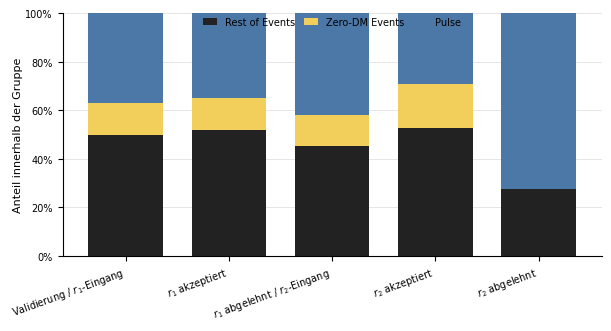

: 

: 

In [ ]:
masks = {
    "Validation / R1 input": np.ones(len(results), dtype=bool),
    "R1 accepted": ~results.r1_rejected,
    "R1 rejected / R2 input": results.r1_rejected,
    "R2 accepted": results.r2_input & ~results.r2_rejected,
    "R2 rejected": results.r2_rejected,
}

parent_sizes = {
    "Validation / R1 input": len(results),
    "R1 accepted": len(results),
    "R1 rejected / R2 input": len(results),
    "R2 accepted": int(results.r2_input.sum()),
    "R2 rejected": int(results.r2_input.sum()),
}
routing_summary = pd.DataFrame([
    {"group": name, "count": int(mask.sum()),
     "percent_of_validation": 100 * mask.mean(),
     "percent_of_rejector_input": 100 * mask.sum() / parent_sizes[name] if parent_sizes[name] else np.nan}
    for name, mask in masks.items()
]).set_index("group")
display(routing_summary.style.format({"percent_of_validation": "{:.2f}%", "percent_of_rejector_input": "{:.2f}%"}))

label_counts = pd.concat(
    {name: results.loc[mask, "label"].value_counts().reindex(LABEL_MAP.values(), fill_value=0)
     for name, mask in masks.items()}, axis=1
).T
label_percent = label_counts.div(label_counts.sum(axis=1), axis=0).mul(100)
display(label_counts.style.set_caption("Label counts"))
display(label_percent.style.format("{:.2f}%").set_caption("Label distribution within each routing group"))

routing_tick_labels = [
    "Validierung / $r_1$-Eingang",
    "$r_1$ akzeptiert",
    "$r_1$ abgelehnt / $r_2$-Eingang",
    "$r_2$ akzeptiert",
    "$r_2$ abgelehnt",
]
label_display = {
    "rest of events": "Rest of Events",
    "zero DM events": "Zero-DM Events",
    "pulses": "Pulse",
}
label_colors = {
    "rest of events": "#222222",
    "zero DM events": "#F2CF5B",
    "pulses": "#4C78A8",
}

fig, ax = plt.subplots(figsize=FIG_FULL, constrained_layout=True)
label_percent.rename(columns=label_display).plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.72,
    color=[label_colors[column] for column in label_percent.columns],
)
ax.set_xlabel("")
ax.set_ylabel("Anteil innerhalb der Gruppe", labelpad=2)
ax.set_xticklabels(routing_tick_labels, rotation=20, ha="right")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PERCENT_0_100)
style_axis(ax, grid_axis="y")
ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    columnspacing=1.0,
    handlelength=1.4,
)
save_pdf(fig, "label_distribution_by_route.pdf")
plt.show()


# train!! just for debugging

In [ ]:
# results = pd.DataFrame(metadata, columns=META_COLUMNS)
# results.insert(0, "sample_index", np.arange(len(results)))
# results["label"] = results["label_raw"].map(LABEL_MAP)
# results["r1_score"] = r1_scores
# results["r1_rejected"] = results["r1_score"] >= R1_THRESHOLD
# results["r2_input"] = results["r1_rejected"]
# results["r2_score"] = r2_scores
# results["r2_rejected"] = (
#     results["r2_input"] & (results["r2_score"] >= R2_THRESHOLD)
# )
# results["final_route"] = np.select(
#     [~results["r1_rejected"], results["r2_rejected"]],
#     ["R1 accepted", "R2 rejected"],
#     default="R2 accepted",
# )
# results["label_binary"] = labels_binary
# results["f_small_prediction"] = small_preds
# results["f_mid_prediction"] = mid_preds
# results["f_large_prediction"] = large_preds
# results["final_prediction"] = np.select(
#     [results["final_route"].eq("R1 accepted"), results["final_route"].eq("R2 accepted")],
#     [results["f_small_prediction"], results["f_mid_prediction"]],
#     default=results["f_large_prediction"],
# ).astype(int)
# results["prediction_correct"] = results["final_prediction"].eq(results["label_binary"])

# # Konsistenzcheck: R2 muss genau für die R1-Rejects vorliegen.
# assert results.loc[results.r2_input, "r2_score"].notna().all()
# assert results.loc[~results.r2_input, "r2_score"].isna().all()
# assert (results.loc[results.final_route.eq("R1 accepted"), "f_small_prediction"] >= 0).all()
# assert (results.loc[results.final_route.eq("R2 accepted"), "f_mid_prediction"] >= 0).all()
# assert (results.loc[results.final_route.eq("R2 rejected"), "f_large_prediction"] >= 0).all()
# results.to_csv(ROUTING_CSV, index=False)
# print(f"Saved per-sample routing: {ROUTING_CSV}")
# results.head()

# # Übersicht: Welcher Anteil des gesamten Validation-Datensatzes endet bei welchem Modell?
# destination_order = ["f_small", "f_mid", "f_large"]
# route_to_model = {
#     "R1 accepted": "f_small",
#     "R2 accepted": "f_mid",
#     "R2 rejected": "f_large",
# }
# route_description = {
#     "f_small": "R1 accepted",
#     "f_mid": "R1 rejected, R2 accepted",
#     "f_large": "R1 rejected, R2 rejected",
# }

# destination = results["final_route"].map(route_to_model)
# destination_counts = destination.value_counts().reindex(destination_order, fill_value=0)
# final_routing_overview = pd.DataFrame({
#     "routing_decision": [route_description[model] for model in destination_order],
#     "sample_count": destination_counts,
#     "percent_of_validation": destination_counts.div(len(results)).mul(100),
# }, index=destination_order)

# assert final_routing_overview["sample_count"].sum() == len(results)
# assert np.isclose(final_routing_overview["percent_of_validation"].sum(), 100.0)
# display(
#     final_routing_overview.style
#     .format({"sample_count": "{:,}", "percent_of_validation": "{:.2f}%"})
#     .set_caption("Finales Routing des gesamten Validation-Datensatzes")
# )

# model_tick_labels = [r"$f_{\mathrm{small}}$", r"$f_{\mathrm{mid}}$", r"$f_{\mathrm{large}}$"]
# fig, ax = plt.subplots(figsize=FIG_SINGLE, constrained_layout=True)
# bars = ax.bar(
#     np.arange(len(destination_order)),
#     final_routing_overview["percent_of_validation"],
#     color=["#4C78A8", "#F2CF5B", "#E45756"],
#     width=0.62,
# )
# ax.bar_label(
#     bars,
#     labels=[f"{value:.1f} %".replace(".", ",") for value in final_routing_overview["percent_of_validation"]],
#     padding=3,
#     fontsize=7,
# )
# ax.set_xticks(np.arange(len(destination_order)), model_tick_labels)
# ax.set_xlabel("Modell", labelpad=4)
# ax.set_ylabel("Anteil der Validierungsdaten", labelpad=2)
# ax.set_ylim(0, 100)
# ax.yaxis.set_major_formatter(PERCENT_0_100)
# style_axis(ax, grid_axis="y")
# save_pdf(fig, "final_routing_overview.pdf")
# plt.show()

# final_routing_overview.to_csv(OUTPUT_DIR / "train_routing_overview.csv")


: 

: 

## SNR und DM: Mittelwert und Varianz

Die Varianz wird als Populationsvarianz (`ddof=0`) berechnet. Ausgegeben werden Eingang sowie beide Ausgänge jedes Rejectors.

In [ ]:
def numeric_summary(frame, group_masks, columns=("snr", "dm")):
    rows = []
    for group, mask in group_masks.items():
        subset = frame.loc[mask]
        for column in columns:
            values = subset[column].dropna().to_numpy()
            rows.append({
                "group": group, "variable": column.upper(), "n": len(values),
                "mean": values.mean() if len(values) else np.nan,
                "variance_ddof0": values.var(ddof=0) if len(values) else np.nan,
                "std_ddof0": values.std(ddof=0) if len(values) else np.nan,
                "min": values.min() if len(values) else np.nan,
                "median": np.median(values) if len(values) else np.nan,
                "max": values.max() if len(values) else np.nan,
            })
    return pd.DataFrame(rows).set_index(["group", "variable"])

numeric_stats = numeric_summary(results, masks)
numeric_stats.to_csv(OUTPUT_DIR / "snr_dm_summary.csv")
display(numeric_stats.style.format(precision=4))

: 

: 

## SNR-Stufen und DM-Verteilungen

,3.400000,3.600000,4.000000,4.100000,4.200000,4.300000,4.400000,4.500000,4.600000,4.700000,4.800000,4.900000,5.000000,5.100000,5.200000,5.300000,5.400000,5.500000,5.600000,5.700000,5.800000,5.900000,6.100000,6.200000,6.300000,6.400000,6.500000,6.700000,6.800000,6.900000,7.000000,7.200000,7.300000,7.500000,7.600000,7.800000,7.900000,8.000000,8.200000,8.400000,8.500000,9.600000,9.700000,10.800000,11.300000,11.500000,11.800000,12.400000,12.500000,13.000000,13.600000,14.000000,14.700000,15.100000,16.100000,17.000000,18.100000,18.600000,21.299999,29.500000,31.900000,42.700001,45.400002,46.400002,56.500000,59.200001,70.199997
Validation / R1 input,256,256,256,256,8960,13056,12800,6656,4096,3072,4096,3328,1536,1536,2304,1792,1792,768,1024,768,768,256,256,768,1024,512,512,512,512,256,1024,512,512,768,512,512,256,256,512,256,256,256,256,512,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256
R1 accepted,256,1,145,244,5188,8290,8140,3332,2410,2267,2144,2199,627,958,1303,1146,985,481,723,744,600,242,240,718,949,476,463,364,485,242,784,415,493,729,487,486,244,244,494,248,246,249,252,499,236,192,251,256,253,256,255,253,254,251,254,256,254,256,256,255,256,255,251,256,256,223,239
R1 rejected / R2 input,0,255,111,12,3772,4766,4660,3324,1686,805,1952,1129,909,578,1001,646,807,287,301,24,168,14,16,50,75,36,49,148,27,14,240,97,19,39,25,26,12,12,18,8,10,7,4,13,20,64,5,0,3,0,1,3,2,5,2,0,2,0,0,1,0,1,5,0,0,33,17
R2 accepted,0,255,111,0,2352,2439,2792,2000,971,365,955,639,751,550,441,440,537,244,261,16,113,4,8,31,51,32,40,125,19,11,235,90,14,23,11,18,4,8,4,6,7,5,0,0,10,64,0,0,0,0,1,0,2,4,2,0,1,0,0,0,0,0,5,0,0,33,9
R2 rejected,0,0,0,12,1420,2327,1868,1324,715,440,997,490,158,28,560,206,270,43,40,8,55,10,8,19,24,4,9,23,8,3,5,7,5,16,14,8,8,4,14,2,3,2,4,13,10,0,5,0,3,0,0,3,0,1,0,0,1,0,0,1,0,1,0,0,0,0,8


,Rest of Events,3.x,4.x,5.x,6.x,7.x,8.x,9+
Validation / R1 input,85760,512,56576,12544,4352,4096,1280,6912
R1 accepted,62466,257,34359,7809,3937,3638,1232,6724
R1 rejected / R2 input,23294,255,22217,4735,415,458,48,188
R2 accepted,19018,255,12624,3357,317,395,25,136
R2 rejected,4276,0,9593,1378,98,63,23,52


Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/snr_dm_routing_distributions.pdf


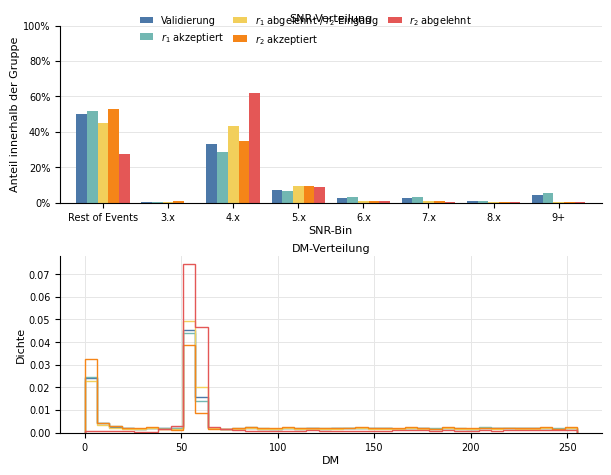

: 

: 

In [ ]:
snr_level_counts = pd.concat(
    {name: results.loc[mask, "snr"].value_counts().sort_index() for name, mask in masks.items()},
    axis=1,
).fillna(0).astype(int)
snr_level_percent = snr_level_counts.div(snr_level_counts.sum(axis=0), axis=1).mul(100)
snr_level_counts.to_csv(OUTPUT_DIR / "snr_level_counts.csv")
snr_level_percent.to_csv(OUTPUT_DIR / "snr_level_percent_within_route.csv")
display(snr_level_counts.T.style.set_caption("Exact SNR-level counts per routing group"))

# Noise = Samples ohne SNR; danach 3.x, 4.x, ..., 8.x und 9+.
snr_numeric_bin_labels = [f"{value}.x" for value in range(3, 9)] + ["9+"]
snr_bin_labels = ["Rest of Events"] + snr_numeric_bin_labels
snr_bins = list(range(3, 10)) + [np.inf]
results["snr_bin"] = pd.cut(
    results["snr"], bins=snr_bins, labels=snr_numeric_bin_labels, right=False, include_lowest=True
)
results["snr_bin"] = results["snr_bin"].cat.add_categories(["Rest of Events"])
results.loc[results["snr"].isna(), "snr_bin"] = "Rest of Events"
snr_bin_counts = pd.concat(
    {name: results.loc[mask, "snr_bin"].value_counts(sort=False).reindex(snr_bin_labels, fill_value=0)
     for name, mask in masks.items()}, axis=1
).astype(int)
snr_bin_percent = snr_bin_counts.div(snr_bin_counts.sum(axis=0), axis=1).mul(100)
snr_bin_counts.to_csv(OUTPUT_DIR / "snr_bin_counts.csv")
snr_bin_percent.to_csv(OUTPUT_DIR / "snr_bin_percent_within_route.csv")
display(snr_bin_counts.T.style.set_caption("SNR-bin counts per routing group"))

routing_display = {
    "Validation / R1 input": "Validierung",
    "R1 accepted": r"$r_1$ akzeptiert",
    "R1 rejected / R2 input": r"$r_1$ abgelehnt / $r_2$-Eingang",
    "R2 accepted": r"$r_2$ akzeptiert",
    "R2 rejected": r"$r_2$ abgelehnt",
}
routing_colors = ["#4C78A8", "#72B7B2", "#F2CF5B", "#F58518", "#E45756"]

fig, axes = plt.subplots(2, 1, figsize=FIG_FULL_DOUBLE, constrained_layout=True)

snr_bin_percent.rename(columns=routing_display).plot(
    kind="bar",
    ax=axes[0],
    width=0.82,
    color=routing_colors,
)
axes[0].set_title("SNR-Verteilung", pad=3)
axes[0].set_xlabel("SNR-Bin", labelpad=2)
axes[0].set_ylabel("Anteil innerhalb der Gruppe", labelpad=2)
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(PERCENT_0_100)
axes[0].tick_params(axis="x", rotation=0)
style_axis(axes[0], grid_axis="y")

for (name, mask), color in zip(masks.items(), routing_colors):
    axes[1].hist(
        results.loc[mask, "dm"],
        bins=40,
        density=True,
        histtype="step",
        linewidth=1.0,
        color=color,
        label=routing_display[name],
    )
axes[1].set_title("DM-Verteilung", pad=3)
axes[1].set_xlabel("DM", labelpad=2)
axes[1].set_ylabel("Dichte", labelpad=2)
style_axis(axes[1], grid_axis="both")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
axes[1].legend().remove()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
    columnspacing=1.0,
    handlelength=1.4,
)
save_pdf(fig, "snr_dm_routing_distributions.pdf")
plt.show()


In [ ]:
# Anteil der finalen Modellrouten innerhalb jedes SNR-Bins
route_order = ["R1 accepted", "R2 accepted", "R2 rejected"]
route_labels = {
    "R1 accepted": "f_small (R1 accepted)",
    "R2 accepted": "f_mid (R2 accepted)",
    "R2 rejected": "f_large (R2 rejected)",
}
snr_route_counts = pd.crosstab(
    results["snr_bin"], results["final_route"], dropna=True
).reindex(index=snr_bin_labels, columns=route_order, fill_value=0)
snr_route_counts.columns = [route_labels[column] for column in snr_route_counts.columns]

samples_per_snr_bin = snr_route_counts.sum(axis=1)
snr_route_percent = snr_route_counts.div(samples_per_snr_bin.replace(0, np.nan), axis=0).mul(100)
snr_validation_summary = pd.concat([
    samples_per_snr_bin.rename("validation_count"),
    samples_per_snr_bin.div(samples_per_snr_bin.sum()).mul(100).rename("percent_of_validation"),
    snr_route_percent,
], axis=1)
display(
    snr_validation_summary.style
    .format({column: "{:.2f}%" for column in snr_validation_summary.columns if column != "validation_count"})
    .set_caption("Validation-SNR-Verteilung und bedingte Modellroute je SNR-Bin")
)

n_without_snr = int(results["snr"].isna().sum())
print(f"Validation samples: {samples_per_snr_bin.sum():,}; davon Rest of Events ohne SNR: {n_without_snr:,}")

snr_route_counts.to_csv(OUTPUT_DIR / "snr_route_counts_by_bin.csv")
snr_route_percent.to_csv(OUTPUT_DIR / "snr_route_percent_by_bin.csv")
snr_validation_summary.to_csv(OUTPUT_DIR / "snr_validation_and_routes_by_bin.csv")


,validation_count,percent_of_validation,f_small (R1 accepted),f_mid (R2 accepted),f_large (R2 rejected)
snr_bin,,,,,
Rest of Events,85760,49.85%,72.84%,22.18%,4.99%
3.x,512,0.30%,50.20%,49.80%,0.00%
4.x,56576,32.89%,60.73%,22.31%,16.96%
5.x,12544,7.29%,62.25%,26.76%,10.99%
6.x,4352,2.53%,90.46%,7.28%,2.25%
7.x,4096,2.38%,88.82%,9.64%,1.54%
8.x,1280,0.74%,96.25%,1.95%,1.80%
9+,6912,4.02%,97.28%,1.97%,0.75%


Validation samples: 172,032; davon Rest of Events ohne SNR: 85,760


: 

: 

Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/snr_route_distribution.pdf


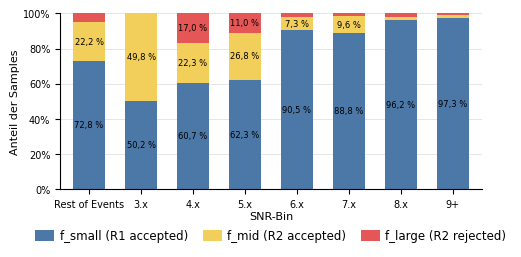

: 

: 

In [ ]:
# ------------------------------------------------------------
# Plot
# Native Größe für 0.7\textwidth
# ------------------------------------------------------------

FIG_80 = (4.85, 2.55)  # 0.8 * ~6.06"

fig, ax = plt.subplots(
    figsize=FIG_80,
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.12,
    right=0.99,
    bottom=0.28,
    top=0.97,
)

snr_route_percent = snr_route_percent.rename(index={"Noise": "Rest of Events"})

snr_route_percent.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.62,
    color=[
        "#4C78A8",
        "#F2CF5B",
        "#E45756",
    ],
)

# ------------------------------------------------------------
# Segmentbeschriftungen
# ------------------------------------------------------------

# Segmentbeschriftungen
for x_pos, (_, row) in enumerate(snr_route_percent.iterrows()):
    bottom = 0.0

    for value in row:
        if pd.isna(value) or value <= 0:
            continue

        if value >= 6:
            ax.text(
                x_pos,
                bottom + value / 2,
                f"{value:.1f} %".replace(".", ","),
                ha="center",
                va="center",
                fontsize=6,
            )

        bottom += value

# ------------------------------------------------------------
# Achsen
# ------------------------------------------------------------

ax.set_xlabel(
    "SNR-Bin",
    labelpad=2,
)

ax.set_ylabel(
    "Anteil der Samples",
    labelpad=2,
)

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    PERCENT_0_100
)

ax.tick_params(
    axis="x",
    rotation=0,
)

style_axis(
    ax,
    grid_axis="y",
)


# ------------------------------------------------------------
# Legende unterhalb des Plots
# ------------------------------------------------------------

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=3,
    frameon=False,
    borderaxespad=0.0,
    fontsize=8.5,
    columnspacing=1.2,
    handlelength=1.6,
    handleheight=1.1,
    handletextpad=0.5,
)

# ------------------------------------------------------------
# Speichern
# ------------------------------------------------------------

save_pdf(
    fig,
    "snr_route_distribution.pdf",
)

plt.show()

,input_count,rejected_count,mean_reject_score,accepted_count,accepted_percent
snr_bin,,,,,
Rest of Events,85760,23294,0.4765,62466,72.84%
3.x,512,255,0.5508,257,50.20%
4.x,56576,22217,0.5202,34359,60.73%
5.x,12544,4735,0.4544,7809,62.25%
6.x,4352,415,0.1795,3937,90.46%
7.x,4096,458,0.1800,3638,88.82%
8.x,1280,48,0.0867,1232,96.25%
9+,6912,188,0.0653,6724,97.28%


Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/r1_acceptance_by_snr_bin.pdf


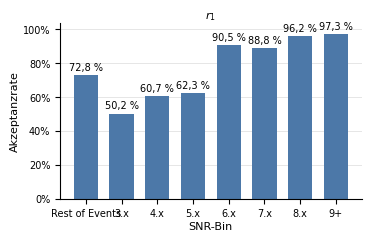

,input_count,rejected_count,mean_reject_score,accepted_count,accepted_percent
snr_bin,,,,,
Rest of Events,23294,4276,0.1658,19018,81.64%
3.x,255,0,0.0010,255,100.00%
4.x,22217,9593,0.3627,12624,56.82%
5.x,4735,1378,0.2716,3357,70.90%
6.x,415,98,0.2389,317,76.39%
7.x,458,63,0.1387,395,86.24%
8.x,48,23,0.4017,25,52.08%
9+,188,52,0.2200,136,72.34%


Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/r2_acceptance_by_snr_bin.pdf


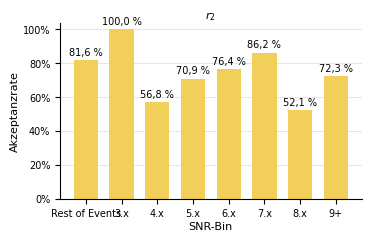

: 

: 

In [ ]:
# Akzeptanzrate und mittlerer Reject-Score je SNR-Bin, separat für R1 und R2
def acceptance_by_snr_bin(frame, input_mask, rejected_column, score_column):
    subset = frame.loc[input_mask].copy()
    grouped = subset.groupby("snr_bin", observed=False)
    summary = grouped.agg(
        input_count=(rejected_column, "size"),
        rejected_count=(rejected_column, "sum"),
        mean_reject_score=(score_column, "mean"),
    ).reindex(snr_bin_labels)
    summary["accepted_count"] = summary["input_count"] - summary["rejected_count"]
    summary["accepted_percent"] = (
        summary["accepted_count"].div(summary["input_count"].replace(0, np.nan)).mul(100)
    )
    return summary


def plot_acceptance(summary, rejector_label, color, save_name):
    values = summary["accepted_percent"].to_numpy(dtype=float)
    x = np.arange(len(summary))

    fig, ax = plt.subplots(figsize=FIG_SINGLE, constrained_layout=True)
    bars = ax.bar(
        x,
        np.nan_to_num(values, nan=0.0),
        color=color,
        width=0.68,
    )
    labels = [
        f"{value:.1f} %".replace(".", ",") if np.isfinite(value) else "n=0"
        for value in values
    ]
    ax.bar_label(bars, labels=labels, padding=2, fontsize=7)
    ax.set_xticks(x, summary.index)
    ax.set_ylim(0, 104)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_title(rejector_label, pad=3)
    ax.set_xlabel("SNR-Bin", labelpad=2)
    ax.set_ylabel("Akzeptanzrate", labelpad=2)
    ax.yaxis.set_major_formatter(PERCENT_0_100)
    ax.tick_params(axis="x", rotation=0)
    style_axis(ax, grid_axis="y")
    save_pdf(fig, save_name)
    plt.show()


r1_snr_acceptance = acceptance_by_snr_bin(
    results, np.ones(len(results), dtype=bool), "r1_rejected", "r1_score"
)
display(
    r1_snr_acceptance.style
    .format({"mean_reject_score": "{:.4f}", "accepted_percent": "{:.2f}%"})
    .set_caption("R1: Eingang, Reject-Score und Acceptance-Rate je SNR-Bin")
)
plot_acceptance(
    r1_snr_acceptance,
    r"$r_1$",
    "#4C78A8",
    "r1_acceptance_by_snr_bin.pdf",
)

# R2 wird nur auf seinem tatsächlichen Eingang ausgewertet: den R1-Rejects.
r2_snr_acceptance = acceptance_by_snr_bin(
    results, results["r2_input"], "r2_rejected", "r2_score"
)
display(
    r2_snr_acceptance.style
    .format({"mean_reject_score": "{:.4f}", "accepted_percent": "{:.2f}%"})
    .set_caption("R2: Eingang, Reject-Score und Acceptance-Rate je SNR-Bin (nur R1-Rejects)")
)
plot_acceptance(
    r2_snr_acceptance,
    r"$r_2$",
    "#F2CF5B",
    "r2_acceptance_by_snr_bin.pdf",
)

r1_snr_acceptance.to_csv(OUTPUT_DIR / "r1_acceptance_by_snr_bin.csv")
r2_snr_acceptance.to_csv(OUTPUT_DIR / "r2_acceptance_by_snr_bin.csv")


,routing_group,n_routed_samples,n_correct,n_incorrect,validation_accuracy,full_validation_accuracy
model,,,,,,
f_small,R1 accepted,120422,96607,23815,80.2237%,74.0000%
f_mid,R2 accepted,36127,35893,234,99.3523%,94.8000%
f_large,R2 rejected,15483,15333,150,99.0312%,99.3400%


Gesamte kaskadierte Validation-Accuracy: 85.9334%
Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/routed_model_validation_accuracy.pdf


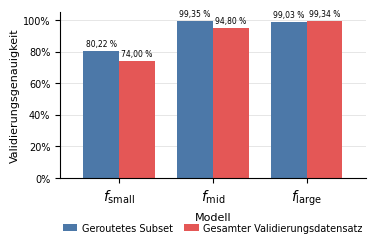

In [15]:
# Validation-Accuracy jedes Klassifikators ausschließlich auf seiner finalen Route

model_routes = [
    ("f_small", "R1 accepted", "f_small_prediction"),
    ("f_mid", "R2 accepted", "f_mid_prediction"),
    ("f_large", "R2 rejected", "f_large_prediction"),
]


accuracy_rows = []

for model_name, route_name, prediction_column in model_routes:
    route_mask = results["final_route"].eq(route_name)

    correct = results.loc[
        route_mask,
        prediction_column,
    ].eq(
        results.loc[
            route_mask,
            "label_binary",
        ]
    )

    accuracy_rows.append({
        "model": model_name,
        "routing_group": route_name,
        "n_routed_samples": int(route_mask.sum()),
        "n_correct": int(correct.sum()),
        "n_incorrect": int((~correct).sum()),
        "validation_accuracy": (
            correct.mean()
            if len(correct)
            else np.nan
        ),
    })


routed_accuracy = (
    pd.DataFrame(accuracy_rows)
    .set_index("model")
)

routed_accuracy["full_validation_accuracy"] = pd.Series({
    "f_small": 0.7400,
    "f_mid": 0.9480,
    "f_large": 0.9934,
})


pipeline_accuracy = results["prediction_correct"].mean()


display(
    routed_accuracy.style
    .format({
        "validation_accuracy": "{:.4%}",
        "full_validation_accuracy": "{:.4%}",
    })
    .set_caption(
        "Validation-Accuracy auf der Modellroute und dem gesamten Datensatz"
    )
)

print(
    f"Gesamte kaskadierte Validation-Accuracy: "
    f"{pipeline_accuracy:.4%}"
)


# ------------------------------------------------------------
# Plot-Daten
# ------------------------------------------------------------

accuracy_plot_data = (
    routed_accuracy[
        [
            "validation_accuracy",
            "full_validation_accuracy",
        ]
    ]
    .mul(100)
    .rename(columns={
        "validation_accuracy": "Geroutetes Subset",
        "full_validation_accuracy": "Gesamter Validierungsdatensatz",
    })
)


# ------------------------------------------------------------
# Figure
# Native Größe für 0.6\textwidth
# ------------------------------------------------------------

FIG_60 = (3.64, 2.55)

fig, ax = plt.subplots(
    figsize=FIG_60,
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.15,
    right=0.99,
    bottom=0.31,  # vorher 0.29
    top=0.96,
)


# ------------------------------------------------------------
# Balken
# ------------------------------------------------------------

accuracy_plot_data.plot(
    kind="bar",
    ax=ax,
    color=[
        "#4C78A8",
        "#E45756",
    ],
    width=0.76,
)


# ------------------------------------------------------------
# Prozentwerte
# ------------------------------------------------------------

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.2f} %".replace(".", ",")
            for value in container.datavalues
        ],
        padding=2,
        fontsize=5.5,
    )


# ------------------------------------------------------------
# Achsen
# ------------------------------------------------------------
ax.set_xticklabels(
    [
        r"$f_{\mathrm{small}}$",
        r"$f_{\mathrm{mid}}$",
        r"$f_{\mathrm{large}}$",
    ],
    rotation=0,
    fontsize=10,
)

ax.set_xlabel(
    "Modell",
    labelpad=4,
    # fontsize=9,
)

ax.set_ylabel(
    "Validierungsgenauigkeit",
    labelpad=2,
)

ax.set_ylim(
    0,
    105,
)

ax.set_yticks(
    np.arange(0, 101, 20)
)

ax.yaxis.set_major_formatter(
    PERCENT_0_100
)

style_axis(
    ax,
    grid_axis="y",
)


# ------------------------------------------------------------
# Legende unterhalb des Plots, eine Zeile
# ------------------------------------------------------------

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),  # vorher -0.19
    ncol=2,
    frameon=False,
    fontsize=7,
    columnspacing=1.1,
    handlelength=1.5,
    handletextpad=0.5,
)


# ------------------------------------------------------------
# Speichern
# ------------------------------------------------------------

save_pdf(
    fig,
    "routed_model_validation_accuracy.pdf",
)

plt.show()


# ------------------------------------------------------------
# Tabellen exportieren
# ------------------------------------------------------------

routed_accuracy.to_csv(
    OUTPUT_DIR / "routed_model_validation_accuracy.csv"
)

pd.DataFrame([
    {
        "pipeline_validation_accuracy": pipeline_accuracy
    }
]).to_csv(
    OUTPUT_DIR / "cascaded_pipeline_validation_accuracy.csv",
    index=False,
)

## Score-Verteilungen und kompakter Export

,R1 (all validation),R2 (R1 rejects only)
count,1.720320e+05,5.161000e+04
mean,4.555104e-01,2.601864e-01
std,2.011238e-01,2.904028e-01
min,7.069945e-22,1.485277e-11
25%,3.603058e-01,1.388860e-03
50%,4.605432e-01,1.338197e-01
75%,5.689224e-01,4.950913e-01
max,9.999987e-01,9.042723e-01


Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/reject_score_overview.pdf


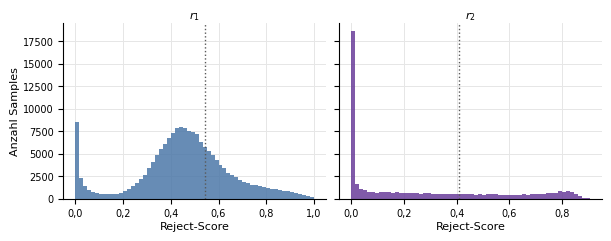

All tables written to /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune


: 

: 

In [ ]:
score_summary = pd.DataFrame({
    "R1 (all validation)": results.r1_score.describe(),
    "R2 (R1 rejects only)": results.loc[results.r2_input, "r2_score"].describe(),
})
display(score_summary)

fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.3), sharey=True, constrained_layout=True)

axes[0].hist(results.r1_score, bins=60, color="#4C78A8", alpha=0.85)
axes[0].axvline(R1_THRESHOLD, color="0.35", linestyle=":", linewidth=1.0)
axes[0].set_title(r"$r_1$", pad=3)
axes[0].set_xlabel("Reject-Score", labelpad=2)
axes[0].set_ylabel("Anzahl Samples", labelpad=2)
axes[0].xaxis.set_major_formatter(COMMA_1)
style_axis(axes[0], grid_axis="both")

axes[1].hist(
    results.loc[results.r2_input, "r2_score"],
    bins=60,
    color="#6a3d9a",
    alpha=0.85,
)
axes[1].axvline(R2_THRESHOLD, color="0.35", linestyle=":", linewidth=1.0)
axes[1].set_title(r"$r_2$", pad=3)
axes[1].set_xlabel("Reject-Score", labelpad=2)
axes[1].xaxis.set_major_formatter(COMMA_1)
style_axis(axes[1], grid_axis="both")

save_pdf(fig, "reject_score_overview.pdf")
plt.show()

label_counts.to_csv(OUTPUT_DIR / "label_counts_by_route.csv")
label_percent.to_csv(OUTPUT_DIR / "label_percent_by_route.csv")
routing_summary.to_csv(OUTPUT_DIR / "routing_summary.csv")
score_summary.to_csv(OUTPUT_DIR / "score_summary.csv")
print(f"All tables written to {OUTPUT_DIR}")


Saved plot: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis_finetune/reject_score_distribution_by_label.pdf


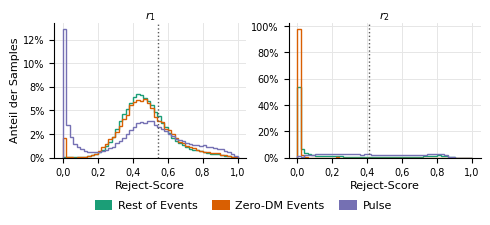

,rejector,label,n_input,mean_reject_score,median_reject_score,accepted_percent,rejected_percent
0,R1,rest of events,85760,0.4765,0.4612,72.84%,27.16%
1,R1,zero DM events,22784,0.4729,0.4635,70.94%,29.06%
2,R1,pulses,63488,0.4209,0.4569,65.83%,34.17%
3,R2,rest of events,23294,0.1658,0.0125,81.64%,18.36%
4,R2,zero DM events,6621,0.0027,0.0000,99.98%,0.02%
5,R2,pulses,21695,0.4402,0.4239,48.35%,51.65%


: 

: 

In [ ]:
# Normalisierte Reject-Score-Verteilungen getrennt nach Metadaten-Label

from matplotlib.patches import Patch


# ------------------------------------------------------------
# Labels / Farben
# ------------------------------------------------------------

label_order = list(LABEL_MAP.values())

label_colors = {
    "rest of events": "#1b9e77",
    "zero DM events": "#d95f02",
    "pulses": "#7570b3",
}

label_display = {
    "rest of events": "Rest of Events",
    "zero DM events": "Zero-DM Events",
    "pulses": "Pulse",
}

score_bins = np.linspace(0.0, 1.0, 51)


# ------------------------------------------------------------
# Thesis-Style
# Native Größe für Einbindung mit 0.8\textwidth
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
})


FIG_80 = (4.85, 2.25)

fig, axes = plt.subplots(
    1,
    2,
    figsize=FIG_80,
    sharex=True,
    sharey=False,
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.11,
    right=0.99,
    bottom=0.30,
    top=0.90,
    wspace=0.22,
)


# ------------------------------------------------------------
# r1
# ------------------------------------------------------------

for label_name in label_order:
    values = (
        results.loc[
            results["label"].eq(label_name),
            "r1_score",
        ]
        .dropna()
        .to_numpy()
    )

    weights = (
        np.full(len(values), 100 / len(values))
        if len(values)
        else None
    )

    axes[0].hist(
        values,
        bins=score_bins,
        weights=weights,
        histtype="step",
        linewidth=1.0,
        linestyle="-",
        color=label_colors[label_name],
    )

axes[0].axvline(
    R1_THRESHOLD,
    color="0.35",
    linestyle=":",
    linewidth=1.0,
)

axes[0].set_title(
    r"$r_1$",
    pad=3,
)

axes[0].set_xlabel(
    "Reject-Score",
    labelpad=2,
)

axes[0].set_ylabel(
    "Anteil der Samples",
    labelpad=2,
)

axes[0].xaxis.set_major_formatter(
    COMMA_1
)

axes[0].yaxis.set_major_formatter(
    PERCENT_0_100
)

style_axis(
    axes[0],
    grid_axis="both",
)


# ------------------------------------------------------------
# r2
# ------------------------------------------------------------

r2_input_results = results.loc[
    results["r2_input"]
]

for label_name in label_order:
    values = (
        r2_input_results.loc[
            r2_input_results["label"].eq(label_name),
            "r2_score",
        ]
        .dropna()
        .to_numpy()
    )

    weights = (
        np.full(len(values), 100 / len(values))
        if len(values)
        else None
    )

    axes[1].hist(
        values,
        bins=score_bins,
        weights=weights,
        histtype="step",
        linewidth=1.0,
        linestyle="-",
        color=label_colors[label_name],
    )

axes[1].axvline(
    R2_THRESHOLD,
    color="0.35",
    linestyle=":",
    linewidth=1.0,
)

axes[1].set_title(
    r"$r_2$",
    pad=3,
)

axes[1].set_xlabel(
    "Reject-Score",
    labelpad=2,
)

axes[1].xaxis.set_major_formatter(
    COMMA_1
)

axes[1].yaxis.set_major_formatter(
    PERCENT_0_100
)

style_axis(
    axes[1],
    grid_axis="both",
)


# ------------------------------------------------------------
# Gemeinsame Legende mit gefüllten Farbfeldern
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=label_colors[label_name],
        edgecolor="none",
        label=label_display[label_name],
    )
    for label_name in label_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=False,
    fontsize=8,
    columnspacing=1.3,
    handlelength=1.6,
    handleheight=1.0,
    handletextpad=0.5,
)


# ------------------------------------------------------------
# Speichern
# ------------------------------------------------------------

save_pdf(
    fig,
    "reject_score_distribution_by_label.pdf",
)

plt.show()


# ------------------------------------------------------------
# Zusammenfassung der Scores / Routingraten
# ------------------------------------------------------------

def score_routing_summary(
    frame,
    score_column,
    rejected_column,
    rejector_name,
):
    rows = []

    for label_name in label_order:
        group = frame.loc[
            frame["label"].eq(label_name)
        ]

        rows.append({
            "rejector": rejector_name,
            "label": label_name,
            "n_input": len(group),
            "mean_reject_score": group[score_column].mean(),
            "median_reject_score": group[score_column].median(),
            "accepted_percent": (
                100 * (~group[rejected_column]).mean()
                if len(group)
                else np.nan
            ),
            "rejected_percent": (
                100 * group[rejected_column].mean()
                if len(group)
                else np.nan
            ),
        })

    return pd.DataFrame(rows)


score_by_label_summary = pd.concat(
    [
        score_routing_summary(
            results,
            "r1_score",
            "r1_rejected",
            "R1",
        ),
        score_routing_summary(
            r2_input_results,
            "r2_score",
            "r2_rejected",
            "R2",
        ),
    ],
    ignore_index=True,
)


display(
    score_by_label_summary.style
    .format({
        "mean_reject_score": "{:.4f}",
        "median_reject_score": "{:.4f}",
        "accepted_percent": "{:.2f}%",
        "rejected_percent": "{:.2f}%",
    })
    .set_caption(
        "Reject-Scores und Routingraten je Metadaten-Label"
    )
)


score_by_label_summary.to_csv(
    OUTPUT_DIR / "rejector_scores_and_routing_by_label.csv",
    index=False,
)

In [1]:
# Normalisierte Reject-Score-Verteilungen für r2,
# getrennt nach Metadaten-Label

from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Labels / Farben
# ------------------------------------------------------------

label_order = list(LABEL_MAP.values())

label_colors = {
    "rest of events": "#1b9e77",
    "zero DM events": "#d95f02",
    "pulses": "#7570b3",
}

label_display = {
    "rest of events": "Rest of Events",
    "zero DM events": "Zero-DM Events",
    "pulses": "Pulse",
}

score_bins = np.linspace(0.0, 1.0, 51)


# ------------------------------------------------------------
# Thesis-Style
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "lines.linewidth": 0.8,
    "lines.markersize": 3.5,
})


fig, ax = plt.subplots(
    figsize=(3.8, 2.3),
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.14,
    right=0.99,
    bottom=0.30,
    top=0.93,
)


# ------------------------------------------------------------
# r2
# ------------------------------------------------------------

r2_input_results = results.loc[
    results["r2_input"]
]

for label_name in label_order:
    values = (
        r2_input_results.loc[
            r2_input_results["label"].eq(label_name),
            "r2_score",
        ]
        .dropna()
        .to_numpy()
    )

    weights = (
        np.full(len(values), 100 / len(values))
        if len(values)
        else None
    )

    ax.hist(
        values,
        bins=score_bins,
        weights=weights,
        histtype="step",
        linewidth=0.8,
        linestyle="-",
        color=label_colors[label_name],
    )


# Reject-Threshold
ax.axvline(
    R2_THRESHOLD,
    color="0.35",
    linestyle=":",
    linewidth=0.8,
)


# ------------------------------------------------------------
# Achsen
# ------------------------------------------------------------

ax.set_xlabel(
    "Reject-Score",
    labelpad=2,
)

ax.set_ylabel(
    "Anteil der Samples",
    labelpad=2,
)

ax.set_xlim(
    0,
    1,
)

ax.set_ylim(
    0,
    10,
)

ax.set_yticks(
    np.arange(0, 10.1, 2),
)

ax.xaxis.set_major_formatter(
    COMMA_1
)

ax.yaxis.set_major_formatter(
    PERCENT_0_100
)

style_axis(
    ax,
    grid_axis="both",
)


# ------------------------------------------------------------
# Legende
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=label_colors[label_name],
        edgecolor="none",
        label=label_display[label_name],
    )
    for label_name in label_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=False,
    fontsize=8,
    columnspacing=1.1,
    handlelength=1.5,
    handleheight=1.0,
    handletextpad=0.5,
)


# ------------------------------------------------------------
# Speichern
# ------------------------------------------------------------

save_pdf(
    fig,
    "r2_reject_score_distribution_by_label_zoom.pdf",
)

plt.show()

NameError: name 'LABEL_MAP' is not defined